##Context:
An over-the-top (OTT) media service is a media service offered directly to viewers via the internet. The term is most synonymous with subscription-based video-on-demand services that offer access to film and television content, including existing series acquired from other producers, as well as original content produced specifically for the service. They are typically accessed via websites on personal computers, apps on smartphones and tablets, or televisions with integrated Smart TV platforms.

Presently, OTT services are at a relatively nascent stage and are widely accepted as a trending technology across the globe. With the increasing change in customers' social behavior, which is shifting from traditional subscriptions to broadcasting services and OTT on-demand video and music subscriptions every year, OTT streaming is expected to grow at a very fast pace. The global OTT market size was valued at $121.61 billion in 2019 and is projected to reach $1,039.03 billion by 2027, growing at a CAGR of 29.4% from 2020 to 2027. The shift from television to OTT services for entertainment is driven by benefits such as on-demand services, ease of access, and access to better networks and digital connectivity.

With the outbreak of COVID-19, OTT services are striving to meet the growing entertainment appetite of viewers, with some platforms already experiencing a 46% increase in consumption and subscriber count as viewers seek fresh content. With innovations and advanced transformations, which will enable the customers to access everything they want in a single space, OTT platforms across the world are expected to increasingly attract subscribers on a concurrent basis.



##Objective:
ShowTime is an OTT service provider and offers a wide variety of content (movies, web shows, etc.) for its users. They want to determine the driver variables for first-day content viewership so that they can take necessary measures to improve the viewership of the content on their platform. Some of the reasons for the decline in viewership of content would be the decline in the number of people coming to the platform, decreased marketing spend, content timing clashes, weekends and holidays, etc. They have hired you as a Data Scientist, shared the data of the current content on their platform, and asked you to analyze the data and come up with a linear regression model to determine the driving factors for first-day viewership.



##Data Description:
The data contains the different factors to analyze for the content. The detailed data dictionary is given below.

##Data Dictionary:
visitors: Average number of visitors, in millions, to the platform in the past week
ad_impressions: Number of ad impressions, in millions, across all ad campaigns for the content (running and completed)
major_sports_event: Any major sports event on the day
genre: Genre of the content
dayofweek: Day of the release of the content
season: Season of the release of the content
views_trailer: Number of views, in millions, of the content trailer
views_content: Number of first-day views, in millions, of the content

#1. Import Libraries and explore the data

In [1059]:
import numpy as np
import pandas as pd

#For visualizating data
import matplotlib.pyplot as plt
import seaborn as sns

#For randomized data splitting
from sklearn.model_selection import train_test_split

#To build linear regression_model
import statsmodels.api as sm

#To check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For statistical tests (e.g., Shapiro-Wilk)
import scipy.stats as stats

Load and Explore the data

In [1060]:
df = pd.read_csv("/content/ottdata.csv")

In [1061]:
df.shape

(1000, 8)

The dataset contains 1,000 observations and 8 features.

In [1062]:
df.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


This provides a quick look at the data structure. It confirms the presence of numerical variables (visitors, views_content) and categorical variables (genre, dayofweek, season). All variables appear correctly loaded.

In [1063]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


The data types are suitable for analysis, with visitors, ad_impressions, views_trailer, and views_content as numerical features, major_sports_event is correctly read as an integer (binary indicator), and categorical features (genre, dayofweek, season) are of type object.

In [1064]:
df.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


The dataset is complete with no missing values (all columns have 1000 non-null entries).

In [1065]:
df.describe()

,visitors,ad_impressions,major_sports_event,views_trailer,views_content
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,1.704290,1434.712290,0.400000,66.91559,0.473400
std,0.231973,289.534834,0.490143,35.00108,0.105914
min,1.250000,1010.870000,0.000000,30.08000,0.220000
25%,1.550000,1210.330000,0.000000,50.94750,0.400000
50%,1.700000,1383.580000,0.000000,53.96000,0.450000
75%,1.830000,1623.670000,1.000000,57.75500,0.520000
max,2.340000,2424.200000,1.000000,199.92000,0.890000


- visitors: Average number of visitors to the platform in the past week is around 1.7 million, with a range of 1.25 to 2.34 million.
- ad_impressions: Ad impressions range from 1010.87 million to 2424.2 million, with an average of 1434.71 million.
- major_sports_event: 40% of the content was released on a day with a major sports event.
- views_trailer: Trailer views range from 30.08 million to 199.92 million, with an average of 66.92 million.
- views_content: First-day views range from 0.22 million to 0.89 million, with an average of 0.473 million.

#2.  EDA (Exploratory Data Analysis)

2.1 Univariate Analysis

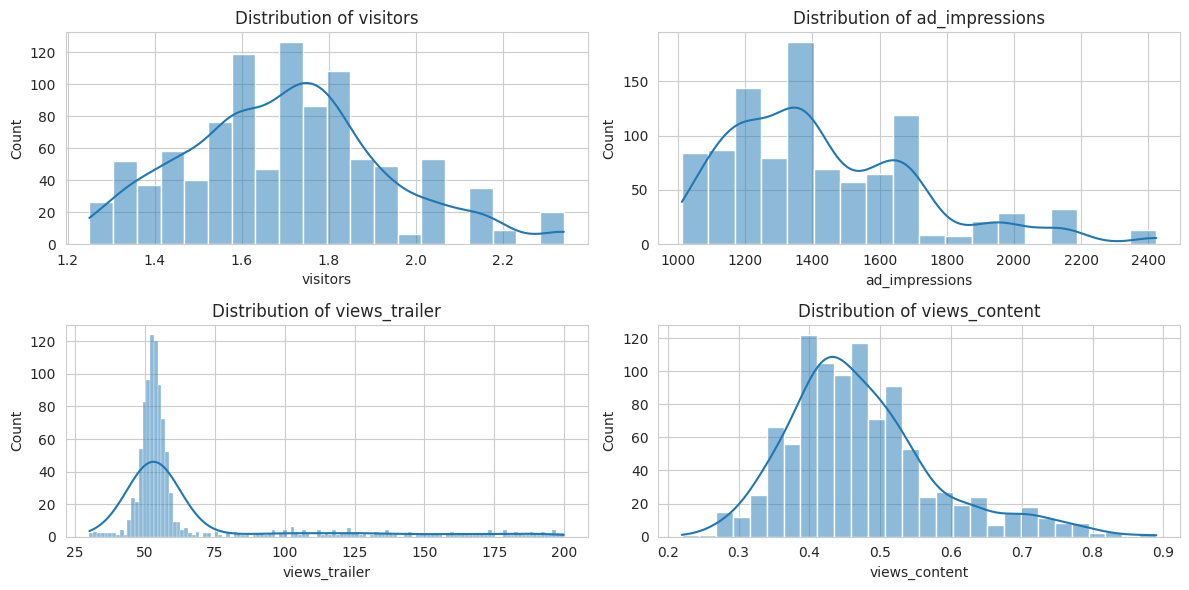

In [1066]:
#Plot distribution of numerical variables
numerical_vars = ['visitors', 'ad_impressions', 'views_trailer', 'views_content']

plt.figure(figsize=(12, 6))
for i, col in enumerate(numerical_vars, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

1. visitors: Distribution looks somewhat normal with a slight right skew.
2. ad_impressions: Slightly right-skewed but overall looks decent.
3. views_trailer: Highly right-skewed (like suspected)
4. views_content: Looks somewhat normal with a slight right skew.

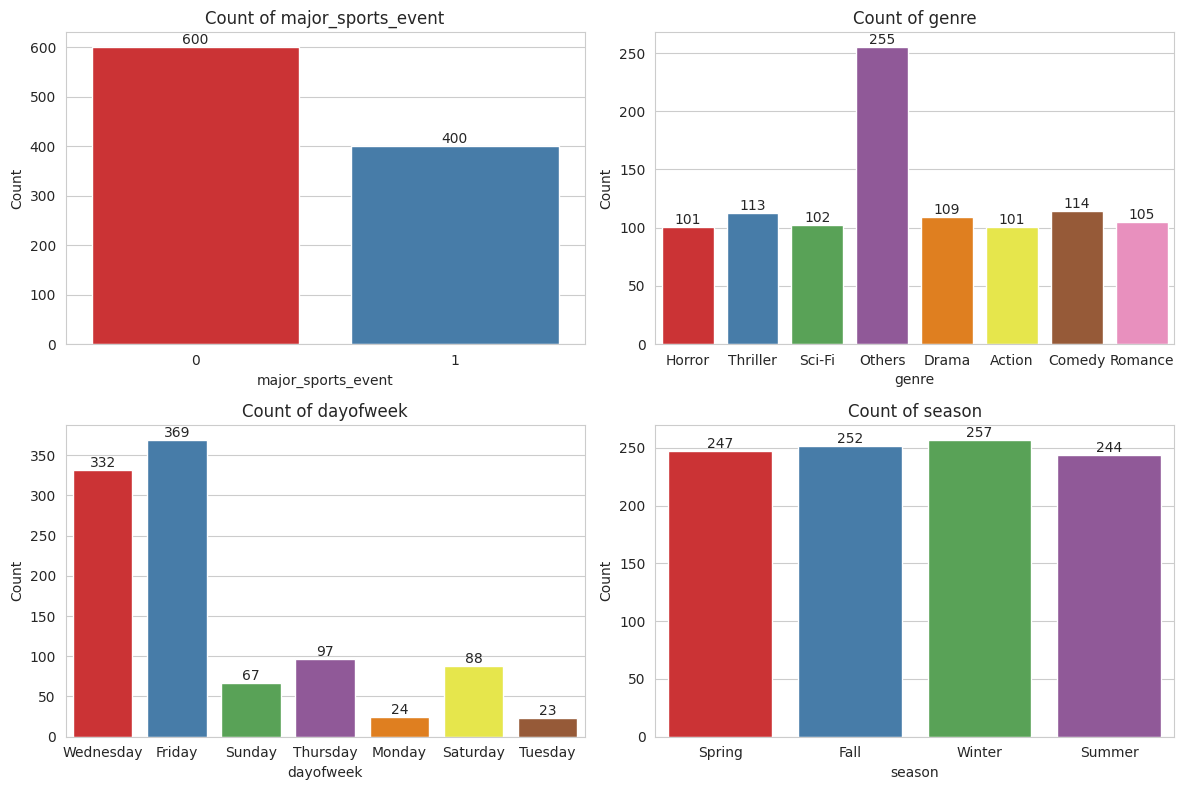

In [1067]:
categorical_cols = ['major_sports_event', 'genre', 'dayofweek', 'season']

plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    ax = sns.countplot(data=df, x=col, hue=col, palette='Set1', legend=False) # Added hue, palette, legend
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

     # Add count labels on top of bars
    for container in ax.containers:
        ax.bar_label(container)
plt.tight_layout()
plt.show()

1. major_sports_event:  More data points when there's no major sports event (600) vs when there is one (400).

2. genre: "Others" genre has the highest count (255). Other genres are somewhat evenly distributed (~100-114).

3. dayofweek: Most data points on Friday (369) and Wednesday (332). Least on Tuesday (23) and Monday (24).

4. season: Counts are similar across seasons (244-257).


2.2 Bivariate Analysis

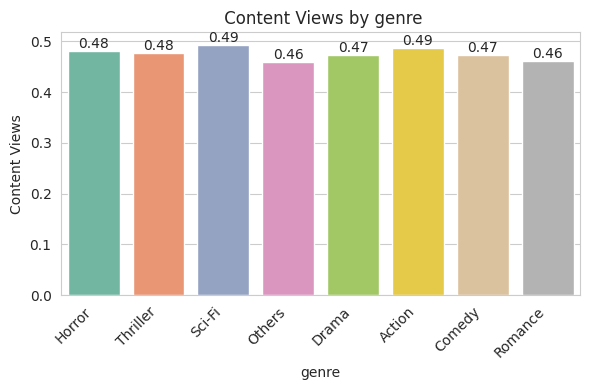

In [1068]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=df, x='genre', y='views_content', palette='Set2', hue='genre', legend=False, errorbar=None)
plt.title(' Content Views by genre')
plt.xlabel('genre')
plt.ylabel('Content Views')
plt.xticks(rotation=45, ha='right')

# Add labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f') # Using %.2f for average values

plt.tight_layout()
plt.show()

- Highest views: SciFi and Action (0.49) million
- Lowest views: Romance and Others (0.46) million
- Tied views: Horror and Thriller (0.48) million
- Middle-range views: Drama and Comedy (0.47) million


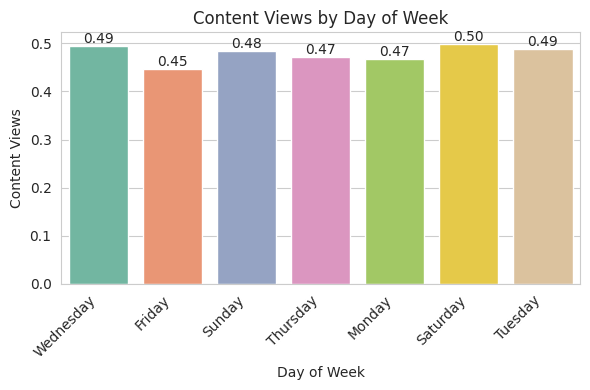

In [1069]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=df, x='dayofweek', y='views_content', palette='Set2', hue='dayofweek', legend=False, errorbar=None)
plt.title('Content Views by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Content Views')
plt.xticks(rotation=45, ha='right')

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()


* Highest content views: Saturday (0.50) million
* Lowest content views: Friday (0.45) million
* Days with similar views: Wednesday and Tuesday (0.49) million, Thursday and Monday (0.47) million, Sunday (0.48) million.

Question: The day of the week on which content is released generally plays a key role in the viewership. How does the viewership vary with the day of release ?

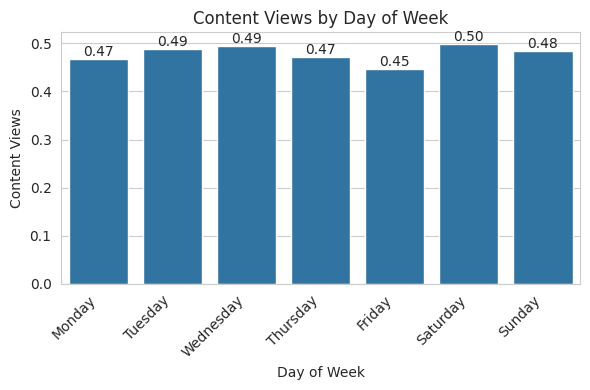

In [1070]:
plt.figure(figsize=(6, 4))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

ax = sns.barplot(
    data=df,
    x='dayofweek',
    y='views_content',
    order=day_order,
    errorbar=None
)

plt.title('Content Views by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Content Views')
plt.xticks(rotation=45, ha='right')

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()


* Highest content views: Saturday (0.50) million
* Lowest content views: Friday (0.45) million
* Overall, weekend releases (especially Saturday) tend to have slightly higher viewership compared to weekdays.

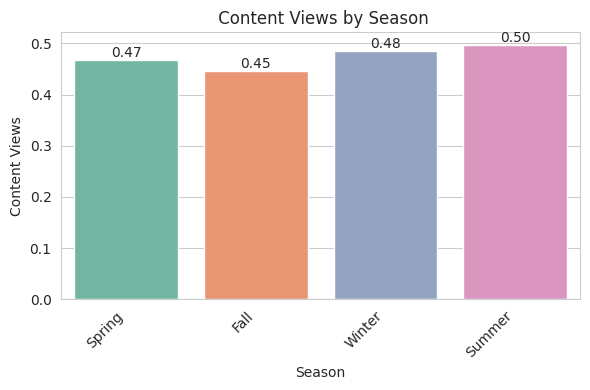

In [1071]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=df, x='season', y='views_content', palette='Set2', hue='season', legend=False, errorbar=None)
plt.title(' Content Views by Season')
plt.xlabel('Season')
plt.ylabel('Content Views')
plt.xticks(rotation=45, ha='right')

# Add labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f') # Using %.2f for average values

plt.tight_layout()
plt.show()

•	Summer has the highest content views at (0.50) million, and Fall has the lowest at (0.45) million

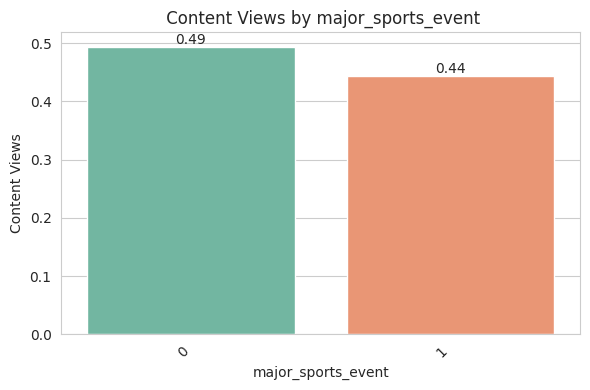

In [1072]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=df, x='major_sports_event', y='views_content', palette='Set2', hue='major_sports_event', legend=False, errorbar=None)
plt.title(' Content Views by major_sports_event')
plt.xlabel('major_sports_event')
plt.ylabel('Content Views')
plt.xticks(rotation=45, ha='right')

# Add labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f') # Using %.2f for average values

plt.tight_layout()
plt.show()

•	There were 0.49 million content views on the first bay when there was no major sports event. And there were 0.44 million content views when there was a major sports event.

Pearson correlation between 'views_trailer' and 'views_content': 0.75


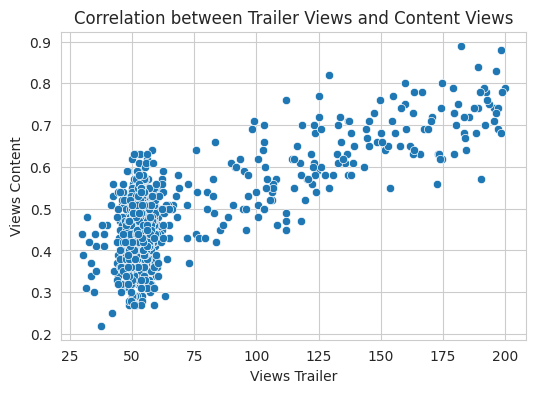

In [1073]:
correlation = df['views_trailer'].corr(df['views_content'])
print(f"Pearson correlation between 'views_trailer' and 'views_content': {correlation:.2f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='views_trailer', y='views_content')
plt.title('Correlation between Trailer Views and Content Views')
plt.xlabel('Views Trailer')
plt.ylabel('Views Content')
plt.grid(True)
plt.show()

•	The scatterplot shows a moderate to strong positive correlation (≈ 0.8 Pearson correlation) between 'Views Trailer' and 'Views Content'. This suggests that as the number of views on the trailer increases, the number of views on the content also tends to increase.

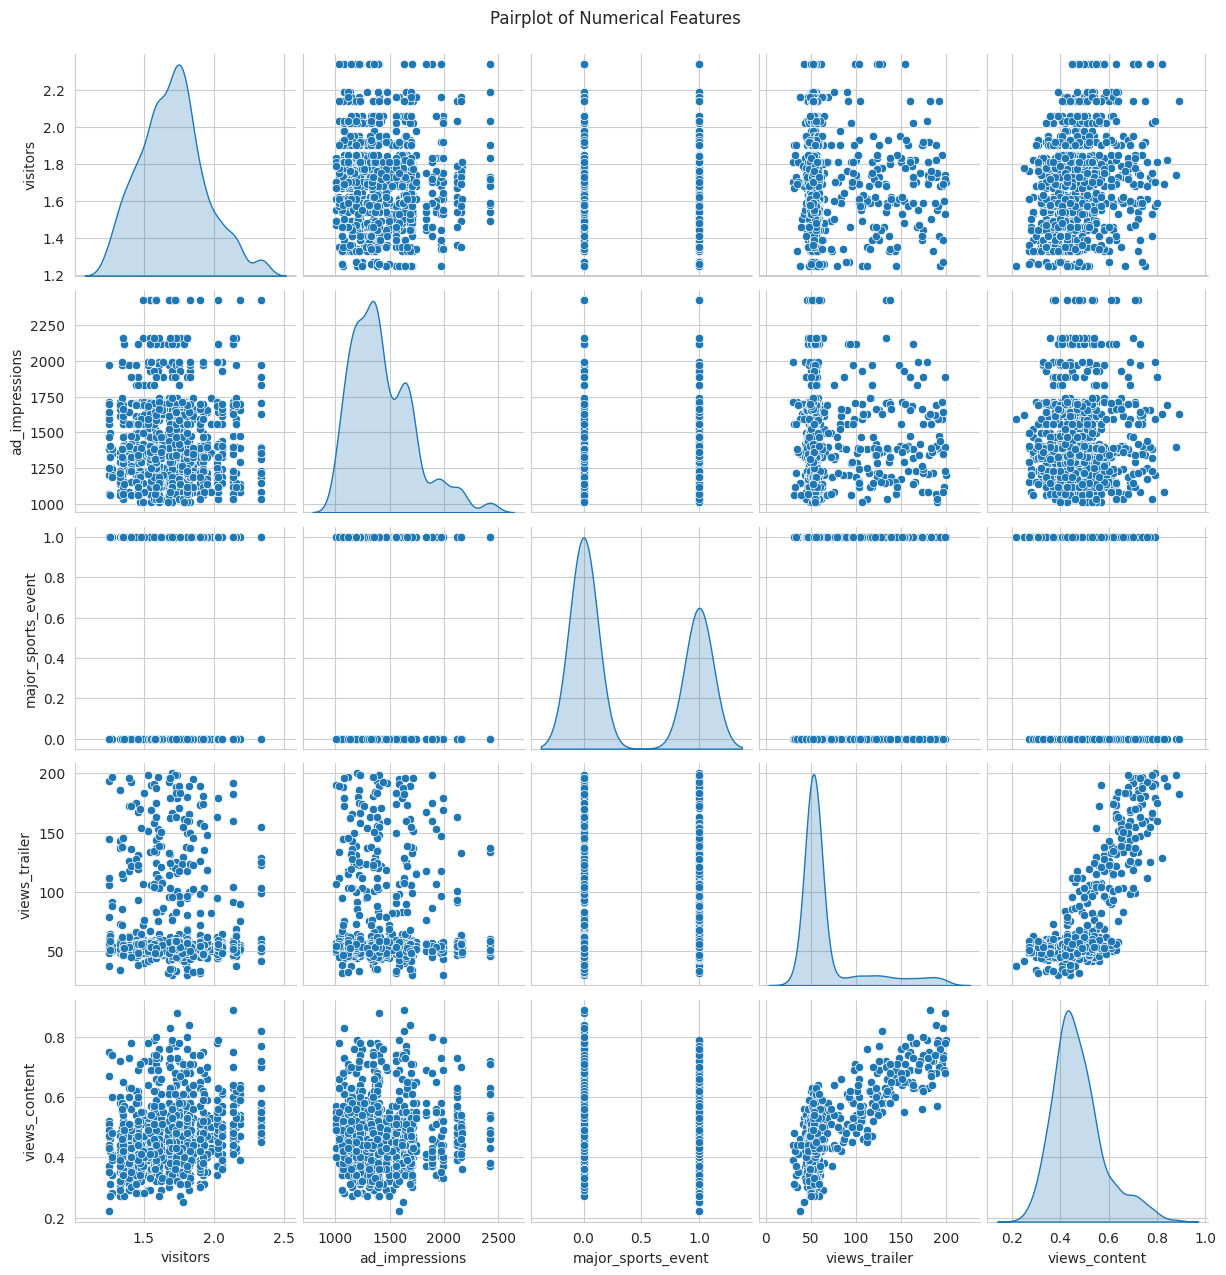

In [1074]:

numerical_df = df.select_dtypes(include=np.number)
sns.pairplot(numerical_df, diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features', y=1.02) # Adjust suptitle to not overlap
plt.show()

* Positive correlation between views_trailer and views_content: As views_trailer increases, views_content tends to increase.
* major_sports_event is binary: Most data points are either 0 or 1, suggesting it's a categorical variable indicating presence/absence of a major sports event
* Visitors distribution is skewed: Peaks around 1.8-2.0, with a tail towards lower values.
* No strong linear correlations with ad_impressions: Scatter plots don't show a clear pattern with most other variables.
* views_trailer and views_content distributions are somewhat similar: Both have a peak and then taper off.


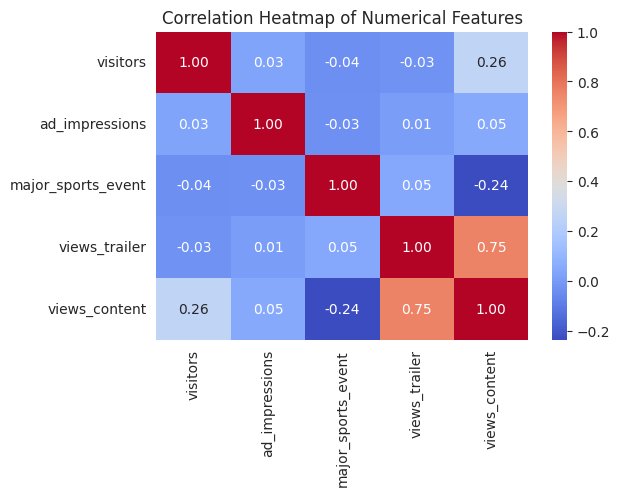

In [1075]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')

plt.show()

* Strong positive correlation between views_trailer and views_content: Correlation coefficient is 0.75, indicating a strong relationship between trailer views and content views.
* major_sports_event has a negative correlation with views_content: Correlation coefficient is -0.24, suggesting that having a major sports event might slightly reduce content views.
* Weak correlations with visitors and ad_impressions: Most correlations involving these variables are close to 0, indicating little to no linear relationship with other variables.


#3 Data Preprocessing

3.1 Check for duplicate values

In [1076]:
# Check number of duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Display duplicated rows (optional)
df[df.duplicated()]

# Remove duplicates if required
df = df.drop_duplicates()


Number of duplicate rows: 0


no duplicate values in the dataset.

3.2 Check for any null values

In [1077]:
df.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


No null values in the dataset.

3.3 Check for Outliers

In [1078]:
numeric_vars = ['visitors', 'ad_impressions', 'views_trailer', 'views_content']

In [1079]:
#Function to detect outliers using IQR
def detect_outliers_iqr(df):
  print("OUTLIER COUNT USING IQR:\n")

outlier_summary = {}

for col in numeric_vars:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
  outlier_summary[col] = outliers

  print(f"{col}: {outliers} outliers")


visitors: 20 outliers
ad_impressions: 13 outliers
views_trailer: 189 outliers
views_content: 47 outliers


After checking for outliers, it was found that visitors had 20 outliers, ad_impressions had 13 outliers, views_trailer had 189 outliers and views_content had 47 outliers.
Outliers were genuine so I considered not to remove the outliers.

In [1080]:
df['log_visitors'] = np.log1p(df['visitors'])
df['log_ad_impressions'] = np.log1p(df['ad_impressions'])
df['log_views_trailer'] = np.log1p(df['views_trailer'])
df['log_views_content'] = np.log1p(df['views_content'])

But the outliers were treated by “Log Transformation” which is  the primary method used to treat the effect of extreme outliers, scaling differences, high skewness in the continuous variables and mainly reduces the influence of outliers. This helps to maintain the Linearity, reduced multi-collinearity.

Logarithmic transformation was the primary method used to treat the effect of extreme outliers and high skewness in the continuous variables (visitors, ad_impressions, views_trailer, and the target views_content).

In [1081]:
#checking outliers after log transformation
numeric_vars = ['log_visitors', 'log_ad_impressions', 'log_views_trailer', 'log_views_content']
for col in numeric_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col}: {outliers} outliers")

log_visitors: 20 outliers
log_ad_impressions: 0 outliers
log_views_trailer: 189 outliers
log_views_content: 40 outliers


After log transformation, there was no outliers in ad_impressions and outliers reduced in views_content, while visitors and views_trailer had same number of outliers, but still even though outliers are found its influence was reduced by log transformation method

3.4 Feature Encoding

In [1082]:
#Independent variables and dependent variable
X = df[['log_visitors', 'log_ad_impressions', 'log_views_trailer',
        'major_sports_event', 'dayofweek', 'season', 'genre']]
y = df["log_views_content"]

X = sm.add_constant(X)

In [1083]:
#Create dummy variables.
X = pd.get_dummies(
    X, columns=X.select_dtypes(include=['object', 'category']).columns.tolist(),
    drop_first=True, dtype=float
)
X.head()

,const,log_visitors,log_ad_impressions,log_views_trailer,major_sports_event,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,...,season_Spring,season_Summer,season_Winter,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,genre_Sci-Fi,genre_Thriller
0,1.0,0.982078,7.016439,4.055257,0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.900161,7.312827,3.983227,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.904218,6.984892,3.906809,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,1.047319,7.203234,3.928093,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.900161,7.312827,4.040064,0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


The nominal categorical features (genre, dayofweek, season) were converted into binary dummy variables using one-hot encoding for inclusion in the linear regression model. One category per feature (e.g., Monday, Action, Spring) was dropped to avoid multicollinearity (the Dummy Variable Trap).

3.5 Data preparation for modelling

Split X and y into train and test sets in a 70:30 ratio.

In [1084]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.30, random_state = 1
)

In [1085]:
print(X_train.head())

     const  log_visitors  log_ad_impressions  log_views_trailer  \
731    1.0      0.970779            7.597662           3.924347   
716    1.0      0.989541            7.677414           4.897317   
640    1.0      0.904218            7.115054           4.009694   
804    1.0      0.912283            6.919555           4.678607   
737    1.0      1.160021            7.021887           3.971046   

     major_sports_event  dayofweek_Monday  dayofweek_Saturday  \
731                   0               0.0                 0.0   
716                   0               0.0                 0.0   
640                   0               0.0                 0.0   
804                   0               0.0                 0.0   
737                   0               0.0                 0.0   

     dayofweek_Sunday  dayofweek_Thursday  dayofweek_Tuesday  ...  \
731               0.0                 0.0                0.0  ...   
716               0.0                 0.0                0.0  ...   

In [1086]:
print(X_test.head())

     const  log_visitors  log_ad_impressions  log_views_trailer  \
507    1.0      0.947789            7.188971           4.074992   
818    1.0      0.932164            7.660741           4.057335   
452    1.0      1.036737            7.050374           5.115476   
368    1.0      1.108563            7.044356           4.110710   
242    1.0      1.011601            6.967777           4.094178   

     major_sports_event  dayofweek_Monday  dayofweek_Saturday  \
507                   0               0.0                 0.0   
818                   0               0.0                 0.0   
452                   0               0.0                 0.0   
368                   0               0.0                 0.0   
242                   0               0.0                 0.0   

     dayofweek_Sunday  dayofweek_Thursday  dayofweek_Tuesday  ...  \
507               1.0                 0.0                0.0  ...   
818               0.0                 1.0                0.0  ...   

#4. Model building - Linear Regression

4.1 Build the model

In [1087]:
olsmod = sm.OLS(y_train, X_train)
olsres = olsmod.fit()

In [1088]:
print(olsres.summary())

                            OLS Regression Results                            
Dep. Variable:      log_views_content   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     117.2
Date:                Sun, 16 Nov 2025   Prob (F-statistic):          1.19e-204
Time:                        17:37:17   Log-Likelihood:                 1388.1
No. Observations:                 700   AIC:                            -2734.
Df Residuals:                     679   BIC:                            -2639.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.4704    

* R-squared	0.775	The model explains 77.5% of the variance in the (log of) first-day content viewership. This indicates a strong model fit.
* Adj. R-squared	0.769	The value is very close to the R-squared, suggesting that the model is not overfitting.
* Prob (F-statistic)	1.19e-204 (approx. 0.000)	The overall model is highly statistically significant.
* No. Observations	700	The model was trained on 700 observations, indicating a 70/30 train-test split was used (70% of the 1000 total observations).

#5. Testing the assumptions of Linear regression model


5.1 Check for Multicolinearity

In [1089]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_check1 = pd.Series(
    [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
    index = X_train.columns,
)
print("VIF values: \n\n{}\n".format(vif_check1))

VIF values: 

const                  1775.350365
log_visitors              1.026600
log_ad_impressions        1.028628
log_views_trailer         1.024735
major_sports_event        1.067140
dayofweek_Monday          1.063373
dayofweek_Saturday        1.155664
dayofweek_Sunday          1.150725
dayofweek_Thursday        1.171144
dayofweek_Tuesday         1.062401
dayofweek_Wednesday       1.315953
season_Spring             1.541472
season_Summer             1.566736
season_Winter             1.568209
genre_Comedy              1.918438
genre_Drama               1.924653
genre_Horror              1.903485
genre_Others              2.574425
genre_Romance             1.753490
genre_Sci-Fi              1.862845
genre_Thriller            1.920768
dtype: float64



* No variables show high multicollinearity (>5) except const which is expected due to the intercept.
- Other variables have VIF close to 1-2, indicating low multicollinearity.

In [1090]:
X_train2 = X_train.drop(['log_ad_impressions', 'genre_Romance', 'genre_Thriller', 'genre_Others',
                         'genre_Horror', 'genre_Comedy', 'genre_Drama', 'genre_Sci-Fi',
                         'dayofweek_Tuesday'], axis = 1)

olsmod_1 = sm.OLS(y_train, X_train2)
olsres_1 = olsmod_1.fit()

print(olsres_1.summary())

                            OLS Regression Results                            
Dep. Variable:      log_views_content   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     212.2
Date:                Sun, 16 Nov 2025   Prob (F-statistic):          1.25e-212
Time:                        17:37:17   Log-Likelihood:                 1383.4
No. Observations:                 700   AIC:                            -2743.
Df Residuals:                     688   BIC:                            -2688.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.4519    


* R-squared: 0.772, Adj. R-squared: 0.769
* Significant predictors (P>|t| < 0.05):
- - log_visitors, log_views_trailer, major_sports_event, all dayofweek, all season
* Coefficients:
- - major_sports_event: negative impact (-0.0431)
- - log_visitors and log_views_trailer: positive impact
* Diagnostics:
- - Durbin-Watson: ~2 (no severe autocorrelation)
- - Prob(Omnibus): 0.075 (slightly above 0.05


5.2 Test for Linearity and Independence

In [1091]:
df_pred = pd.DataFrame()

df_pred["Actual_values"] = y_train.values.flatten()
df_pred["Fitted values"] = olsres_2.fittedvalues.values
df_pred["Residuals"] = olsres_2.resid.values
df_pred.head()

,Actual_values,Fitted values,Residuals
0,0.336472,0.364710,-0.028238
1,0.530628,0.528067,0.002561
2,0.350657,0.361366,-0.010709
3,0.438255,0.459610,-0.021356
4,0.463734,0.434011,0.029723


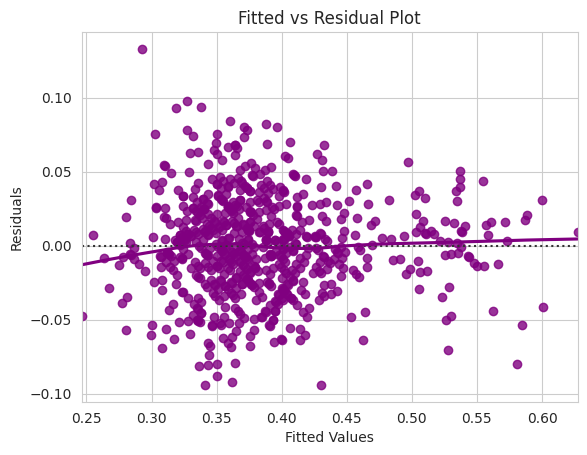

In [1092]:
sns.set_style("whitegrid")
sns.residplot(
    data=df_pred, x="Fitted values", y="Residuals", color="purple", lowess = True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual Plot")
plt.show()

* The points seem to be randomly scattered around the horizontal line (residuals = 0) without any clear pattern or trend. The lowess line (the purple line) is pretty flat and close to the zero line.

* This suggests that the linearity and independence assumptions are likely satisfied. There's no obvious indication of non-linearity or heteroscedasticity (unequal variance) in the residuals based on the plot.

5.3 Test for Normality

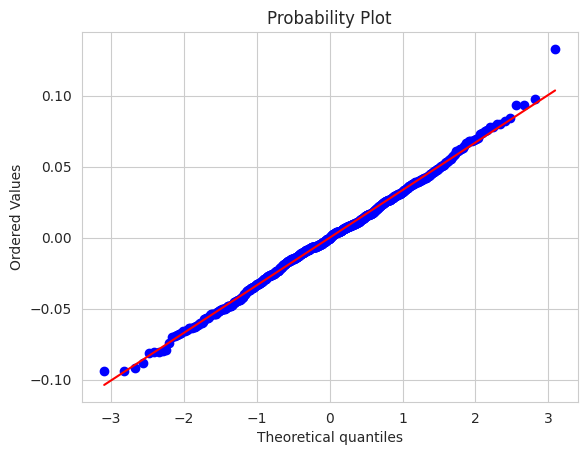

In [1093]:
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

The Q–Q plot shows that residuals lie close to the theoretical normal line, with only minor deviations at the tails. This indicates that the residuals are approximately normally distributed. Therefore, the normality assumption of the linear regression model is reasonably satisfied

In [1094]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=np.float64(0.997337877947397), pvalue=np.float64(0.3180946656942042))

The p-value of 0.318 (>0.05), indicating that we fail to reject the null hypothesis of normality. Therefore, the residuals do not significantly deviate from a normal distribution, and the normality assumption of the linear regression model is satisfied.

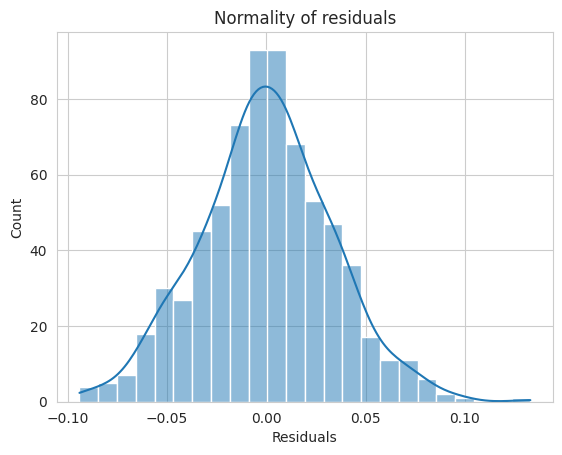

In [1095]:
sns.histplot(df_pred["Residuals"], kde=True)
plt.title("Normality of residuals")
plt.show()

The residual distribution is approximately bell-shaped and centered around zero, indicating that the normality assumption of linear regression is reasonably satisfied. There are no major deviations such as heavy tails or strong skewness. Therefore, the model residuals meet the normality requirement for OLS inference

5.4 Test for Homoscedasticity

In [1096]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

In [1097]:
name = ["F statistics", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], X_train2)
lzip(name, test)

[('F statistics', np.float64(1.172969037601504)),
 ('p-value', np.float64(0.07150451539731567))]

The Goldfeld-Quandt test yielded an F-statistic of 1.173 and a p-value of 0.072, indicating no significant evidence of heteroscedasticity. Thus, we confirm that the residuals exhibit constant variance, supporting the homoscedasticity assumption of our regression model.

All the assumptions of linear regression are now satisfied. Let's check the summary of our final model (olsres_1)

In [1098]:
print(olsres_1.summary())

                            OLS Regression Results                            
Dep. Variable:      log_views_content   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     212.2
Date:                Sun, 16 Nov 2025   Prob (F-statistic):          1.25e-212
Time:                        17:37:18   Log-Likelihood:                 1383.4
No. Observations:                 700   AIC:                            -2743.
Df Residuals:                     688   BIC:                            -2688.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.4519    

#6. Model performance evaluation.

6.1	Coefficient values (Parameters) of the Model:

In [1099]:
#lets check the model parameters
olsres_1.params

,0
const,-0.451897
log_visitors,0.234017
log_views_trailer,0.142665
major_sports_event,-0.043148
dayofweek_Monday,0.020189
dayofweek_Saturday,0.038149
dayofweek_Sunday,0.022894
dayofweek_Thursday,0.009573
dayofweek_Wednesday,0.030704
season_Spring,0.017322


- Positive Influencers:
    - log_visitors has a notable positive impact (0.234017) on the outcome variable.
    - log_views_trailer also positively influences the outcome (0.142665).
    - Among days of the week, Saturday (0.038149) has the highest impact, followed by Wednesday (0.030704).
    - Summer season (0.030223) has a slightly higher impact compared to other seasons.
- Negative Impact:
    - major_sports_event has a slight negative impact (-0.043148) on the outcome.


6.2 Lets print the Linear regression equation.

In [1100]:
#lets write the equation of linear regression
equation = "log_views_content = "
print(equation, end=" ")
for i in range(len(X_train2.columns)):
    if i == 0:
        # Access constant using its label or iloc for position
        print(olsres_1.params.iloc[i], "+", end=" ")
    elif i != len(X_train2.columns) - 1:
        # Access parameter by position and column name by position
        print(
            olsres_1.params.iloc[i],
            " * (",
            X_train2.columns[i],
            ")",
            " + ",
            end=" "
        )
    else:
        # Access parameter by position and column name by position for the last term
        print(olsres_1.params.iloc[i], "* (", X_train2.columns[i], ") ")

log_views_content =  -0.45189722020727174 + 0.234017292896827  * ( log_visitors )  +  0.14266533151888816  * ( log_views_trailer )  +  -0.043148073420038575  * ( major_sports_event )  +  0.020189346367669968  * ( dayofweek_Monday )  +  0.038148643429614666  * ( dayofweek_Saturday )  +  0.022894499220701546  * ( dayofweek_Sunday )  +  0.009573296614542433  * ( dayofweek_Thursday )  +  0.03070410543343042  * ( dayofweek_Wednesday )  +  0.017322123949039238  * ( season_Spring )  +  0.030223308589632583  * ( season_Summer )  +  0.01956804031390859 * ( season_Winter ) 


6.3 Evaluate the model on different performance marks

In [1101]:
X_train2.columns

Index(['const', 'log_visitors', 'log_views_trailer', 'major_sports_event',
       'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday',
       'dayofweek_Thursday', 'dayofweek_Wednesday', 'season_Spring',
       'season_Summer', 'season_Winter'],
      dtype='object')

In [1102]:
X_test.columns

Index(['const', 'log_visitors', 'log_ad_impressions', 'log_views_trailer',
       'major_sports_event', 'dayofweek_Monday', 'dayofweek_Saturday',
       'dayofweek_Sunday', 'dayofweek_Thursday', 'dayofweek_Tuesday',
       'dayofweek_Wednesday', 'season_Spring', 'season_Summer',
       'season_Winter', 'genre_Comedy', 'genre_Drama', 'genre_Horror',
       'genre_Others', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller'],
      dtype='object')

In [1103]:
#dropping columns from the test data that are not there in training data.
X_test2 = X_test.drop(
    ['log_ad_impressions', 'genre_Romance', 'genre_Thriller', 'genre_Others',
                         'genre_Horror', 'genre_Comedy', 'genre_Drama', 'genre_Sci-Fi',
                         'dayofweek_Tuesday'], axis = 1
)

In [1104]:
#lets make predictions on test set
y_pred = olsres_1.predict(X_test2)

In [1105]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf


# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_train_perf = model_performance_regression(olsres_1, X_train2, y_train)
olsmodel_train_perf


Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.033533,0.026255,0.772368,0.768392,7.151303


In [1106]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_test_perf = model_performance_regression(olsres_1, X_test2, y_test)
olsmodel_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.034497,0.027863,0.751143,0.740738,7.548332


- The model explains about 77.2% of the variance in the training data and 75.1% in the test data (R-squared values).
- The RMSE and MAE are low and comparable between training and test sets, indicating no major overfitting.
- MAPE is around 7-7.5%, suggesting decent predictive accuracy.

#7. Actionable Insights & Recommendations

Insights:


1.	Content performance is strongly driven by platform traffic
   * Visitors is one of the strongest predictors of first-day content views.
   * Higher platform traffic directly increases first-day viewership.
2. Trailer engagement is the biggest driver of content success
   * Views_trailer has the largest positive impact (very high t-value).
   * Content with highly-watched trailers consistently gets higher first-day views.
3. Major sports events significantly reduce content views
   * The variable major_sports_event has a strong negative coefficient.
   * First-day views drop significantly if content is released during a major sports event.
4. Seasonal effects matter
   * Summer > Winter > Spring for content performance.
   * Summer releases show the highest average first-day views.
5. Release day influences viewership
   * Saturday, Sunday, and Wednesday show higher content views.
   * Monday and Thursday also perform well but slightly lower.
   * Tuesday releases show comparatively lower views.
6. Genre does NOT significantly impact first-day views
   * Most genre dummy variables have high p-values.
   * Genre choice alone does not determine first-day performance.
7. Model Assumptions are satisfied
   * Residuals are approximately normal (Shapiro–Wilk p > 0.05).
   * No strong heteroskedasticity (BP p > 0.05, GQ test acceptable).
•	Linearity and independence assumptions also hold well.
8. The model explains nearly 79% of variance
   * R² = 0.772 (The model explain around ≈ 77%) shows strong predictive capability.
   * Adjusted R² = 0.7682 confirms the model is robust and not overfitted.

Recommendations:
1. Avoid releasing content on days with major sports events
   * Schedule releases before or after large cricket/football tournaments.
   * Use sports calendars for predictive scheduling.
2. Increase focus on trailer marketing
   * Invest more in trailer promotion, teaser drops, and targeted ad campaigns.
   * Improve trailer quality → this is the strongest revenue driver.
3. Target weekend release strategy
   * Prioritize Saturday and Sunday releases for important content.
   * Wednesday is also a high-performing day.
4. Strategize according to seasonal peaks
   * Plan flagship/original releases during Summer for maximum reach.
   * Use lower-performing seasons (Spring) for niche or experimental content.
5. Optimize platform traffic before release
   * Increase in-app promotions, banners, notifications, and ads in the days before release.
   * Higher visitor volume directly boosts first-day content views.
6. Reduce spending on genre-based marketing
   * Genre has no significant impact → avoid allocating budgets based only on genre assumptions.
   * Focus more on user behaviour, trailer engagement, and timing.
7. Maintain data quality by monitoring outliers
   * While outliers were left untreated for modelling (due to meaningful business context), tracking abnormal spikes in views_trailer or views_content will help detect:
       * 	Viral spikes
       * 	Bot activity
       * 	Paid campaigns
       * 	Crash/error days
8. Model deployment feasibility
   * Since assumptions are satisfied and multicollinearity is manageable, the model can be reliably used for Viewership forecasting
